# Initial stuff


        # Results to save
        "output_fields": [
            "plume_id", # file_id + plume_number
            "plume_number",
            "file_id",
            "file_name",
            "n_points_in_file",
            "timestamp_utc",
            "n_points",
            "max_point_loc",
            "max_point_value",
            "mean_point_value",
            "median_point_value",
            "bbox",
            "area",
            "wind_magnitude",
            "wind_direction",
            "is_weekend",
            "is_on_land",
            "median_of_larger_box",
            "is_max_point_on_edge",
            "is_connected_to_nans",
            "is_connected_to_other_plume",
            "connected_plume_ids",
            "mean_q_value",
        ],


In [1]:
# Initial stuff
import numpy as np
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import cmcrameri.cm as cm
import colorcet as cc
import warnings
from scipy.ndimage import gaussian_filter, uniform_filter
import importlib
import sys

# default colormap to batlow
plt.rcParams['image.cmap'] = 'cmc.batlow'


sys.path.append(os.path.dirname('/Users/eliaserv/Documents/VSCode_projects/SCEA/SCEA_developements/'))

import SCEA_v3 as scea

# reload SCEA_v3 in case of changes
importlib.reload(scea)



<module 'SCEA_v3' from '/Users/eliaserv/Documents/VSCode_projects/SCEA/SCEA_developements/SCEA_v3.py'>

In [2]:
np.array([1, 2, 3]).nanmax()

AttributeError: 'numpy.ndarray' object has no attribute 'nanmax'

In [282]:
# TROPOMI data

tropomi_file = "/Users/eliaserv/Documents/VSCode_projects/SCEA/SCEA_developements/example_data/tropomi_data_example.nc"
#tropomi_file = "/Users/eliaserv/Documents/VSCode_projects/SCEA/SCEA_developements/example_data/S5P_OFFL_L2__NO2____20220620T093952_20220620T112122_24275_02_020301_20220622T014827.nc"

# Whole data
tropomi_data_cropped = xr.open_dataset(tropomi_file, group="PRODUCT", mask_and_scale=True, )


In [283]:
"""
geo = xr.open_dataset(
    "/Users/eliaserv/Documents/VSCode_projects/SCEA/SCEA_developements/example_data/S5P_OFFL_L2__NO2____20220620T093952_20220620T112122_24275_02_020301_20220622T014827.nc",
    group="PRODUCT/SUPPORT_DATA/GEOLOCATIONS",
    engine="netcdf4",
    mask_and_scale=False,
)

from netCDF4 import Dataset

def walk_groups(g, prefix=""):
    for name, sub in g.groups.items():
        p = f"{prefix}/{name}" if prefix else name
        print(p)
        walk_groups(sub, p)

with Dataset(geo, "r") as ds:
    walk_groups(ds)

"""

'\ngeo = xr.open_dataset(\n    "/Users/eliaserv/Documents/VSCode_projects/SCEA/SCEA_developements/example_data/S5P_OFFL_L2__NO2____20220620T093952_20220620T112122_24275_02_020301_20220622T014827.nc",\n    group="PRODUCT/SUPPORT_DATA/GEOLOCATIONS",\n    engine="netcdf4",\n    mask_and_scale=False,\n)\n\nfrom netCDF4 import Dataset\n\ndef walk_groups(g, prefix=""):\n    for name, sub in g.groups.items():\n        p = f"{prefix}/{name}" if prefix else name\n        print(p)\n        walk_groups(sub, p)\n\nwith Dataset(geo, "r") as ds:\n    walk_groups(ds)\n\n'

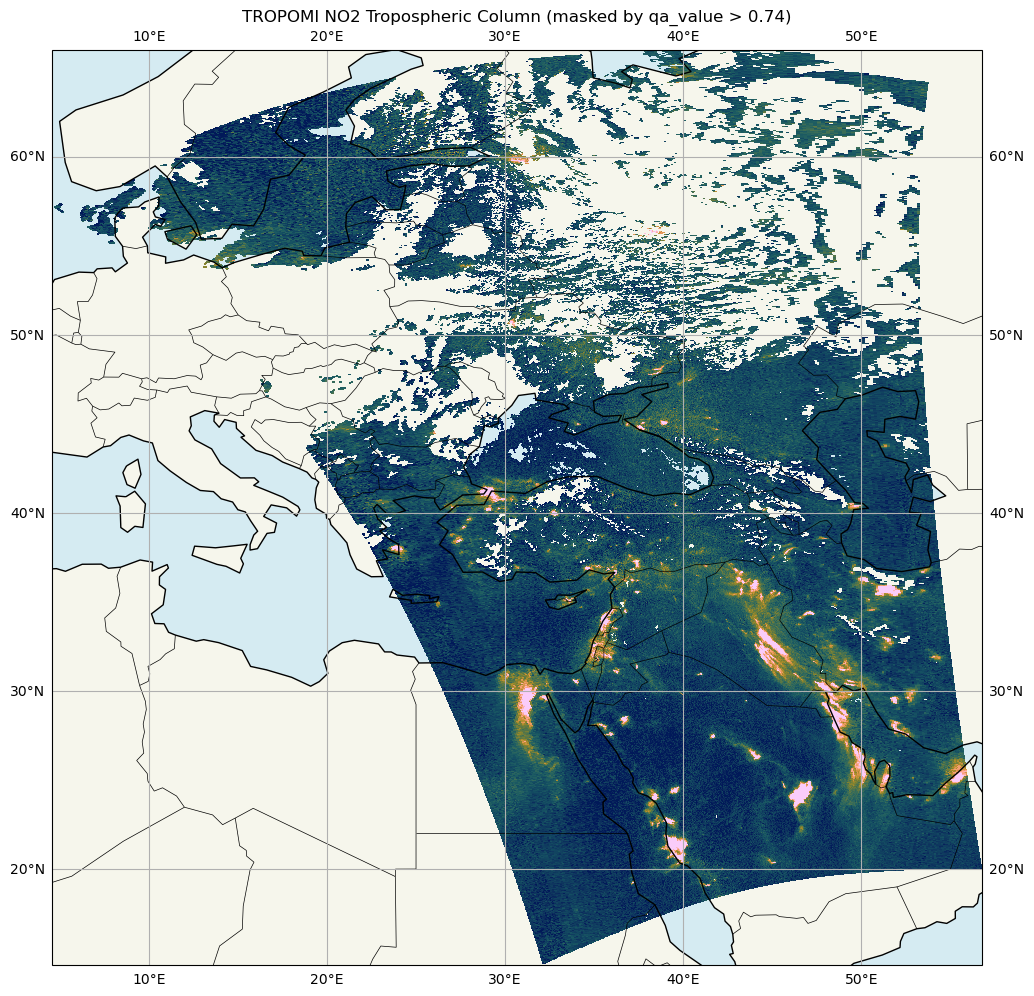

[Init] Starting SCEA with 943 points.
[Init] Warning: 104119 points with NaN values found. They will be ignored.
[Init] Auto threshold set: 0.0000592. (detection_limit=)2.1 standard deviations from median.  (median=0.0000142, std=0.0000214)
[Start] SCEA: metric=geodesic, growth_limit=2.5, detection_limit=2.1, local_box_size=3, max_pts_start_radius=5, n_clusters=auto
[566] Cluster formed. | current max value: 0.0000592 | stopping threshold: 0.0000592
[Stop] Threshold reached: max active 0.0000592 <= 0.0000592
[Done] Total clusters found: 567, Time taken: 7.21 seconds


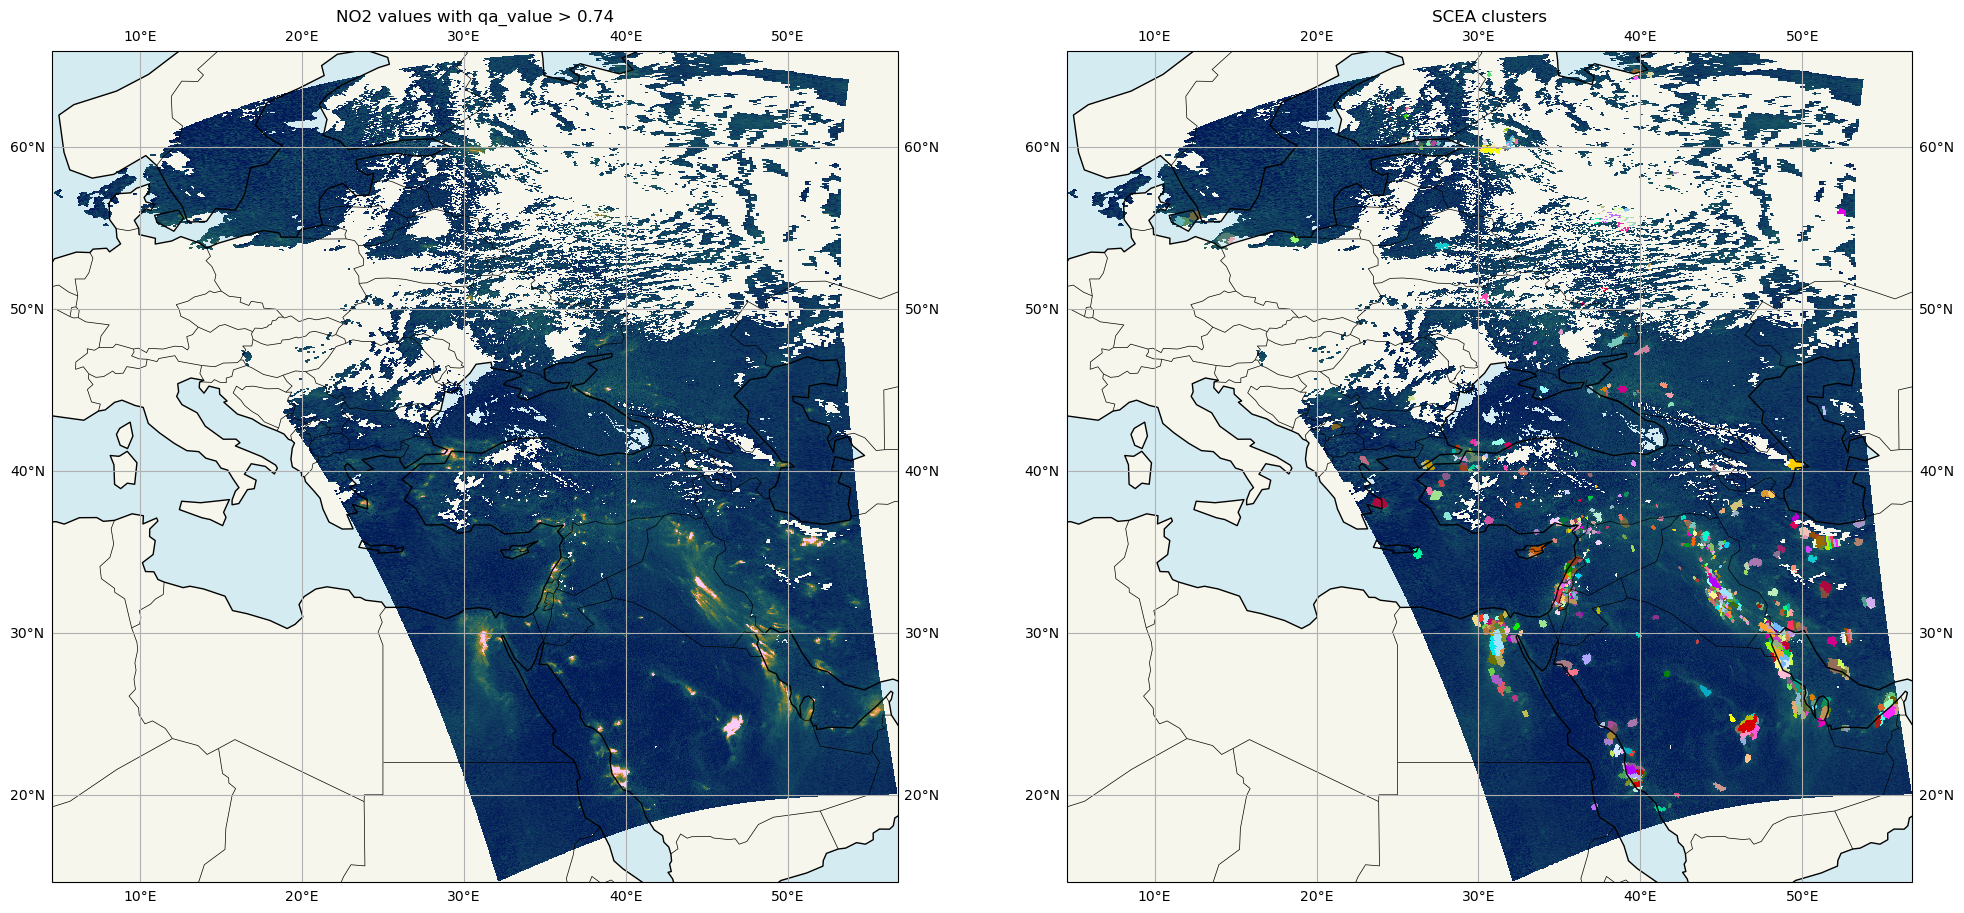

In [284]:
# TROPOMI data


tropomi_file = "/Users/eliaserv/Documents/VSCode_projects/SCEA/SCEA_developements/example_data/tropomi_data_example.nc"

# Whole data
tropomi_data_cropped = xr.open_dataset(tropomi_file, group="PRODUCT", mask_and_scale=True)

# Cropped data
#tropomi_data_cropped = crop_to_bbox(
#        os.path.join(THIS_DIR, tropomi_file),
#        bbox = [20.0, 30.0, 45.0, 50.0]
#        )


# Open era5 data

era5_file = '/Users/eliaserv/Documents/VSCode_projects/SCEA/SCEA_developements/example_data/era5_2024_06_04.nc'
era5_data = xr.open_dataset(era5_file, mask_and_scale=True)
era5_data




# Get only quality data
qa_value=0.74
qa_mask = (tropomi_data_cropped['qa_value'] > qa_value)[0]
no2 = tropomi_data_cropped['nitrogendioxide_tropospheric_column'][0].data
no2_masked = np.where(qa_mask, no2, np.nan) # replace values where qa_mask is False with NaN

# Plotting
fig, ax = plt.subplots(1,1,figsize=(12, 12), subplot_kw={'projection': ccrs.PlateCarree()})
ax.pcolormesh(
    tropomi_data_cropped['longitude'][0].data, 
    tropomi_data_cropped['latitude'][0].data, 
    no2_masked,
    shading='auto',
    vmin=0, vmax=0.0001,
)
# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
ax.gridlines(draw_labels=True)

ax.set_title("TROPOMI NO2 Tropospheric Column (masked by qa_value > 0.74)")

plt.show()



# Find clusters with SCEA


# Longitude and latitude coordinates as (2, ...) array
point_coordinates = np.array(
    [tropomi_data_cropped['longitude'][0].data, 
     tropomi_data_cropped['latitude'][0].data]
     )


# Run the SCEA algorithm
clusters = scea.scea(
    coords=point_coordinates,   # spatial coordinates (lon,lat)
    values=no2_masked,          # values of points (NO2)     
    growth_limit=2.5,           # controls cluster size, higher values means smaller clusters
    detection_limit=2.1,        # controls cluster detection, higher values means less clusters
    local_box_size=3,           # radius of the local area around a starting point to be cropped and standardized (degrees for lon/lat)
    max_pts_start_radius=5,     # stopping criterion for a radiating point, maximum number of points in the starting radius
    metric="geodesic",          # distance metric ("euclidean", "haversine", "geodesic", "half_ellipse", "geodesic_half_ellipse")
    verbose=True                # whether to print progress messages
)

clusters # same shape as no2_masked, with cluster labels for each point (0 means no cluster, 1,2,... are cluster labels)







# Plotting

fig, ax = plt.subplots(1,2,figsize=(24, 12), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot NO2 values
ax[0].pcolormesh(
    tropomi_data_cropped['longitude'][0].data, 
    tropomi_data_cropped['latitude'][0].data, 
    no2_masked,
    shading='auto',
    vmin=0, vmax=0.00018,
)

# Add map features
ax[0].coastlines()
ax[0].add_feature(cfeature.BORDERS, linewidth=0.5)
ax[0].add_feature(cfeature.LAND, alpha=0.5)
ax[0].add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
ax[0].gridlines(draw_labels=True)

ax[0].set_title("NO2 values with qa_value > 0.74")



# Plot NO2 values
ax[1].pcolormesh(
    tropomi_data_cropped['longitude'][0].data, 
    tropomi_data_cropped['latitude'][0].data, 
    no2_masked,
    shading='auto',
    vmin=0, vmax=0.00018,
)

# Cluster label 0 to nan before plotting
clusters_plot = np.where(clusters == 0, np.nan, clusters)

# Plot clusters
ax[1].pcolormesh(
    tropomi_data_cropped['longitude'][0].data, 
    tropomi_data_cropped['latitude'][0].data, 
    clusters_plot,
    shading='auto',
    cmap=cc.cm.glasbey_light, # categorical colormap for clusters
)

ax[1].coastlines()
ax[1].add_feature(cfeature.BORDERS, linewidth=0.5)
ax[1].add_feature(cfeature.LAND, alpha=0.5)
ax[1].add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
ax[1].gridlines(draw_labels=True)

ax[1].set_title("SCEA clusters")
plt.show()

In [285]:
i=170
j=370
clusters[10+i:40+i, 10+j:21+j]

array([[ 14.,  40.,  40.,  40.,  40.,  40.,  40., 386.,   0.,   0.,   0.],
       [ 14.,  40.,  40.,  40.,  40.,  40.,  40., 386.,   0.,   0.,   0.],
       [ 14.,  40.,  40.,  40.,  40.,  40.,  40.,   0.,   0.,   0.,   0.],
       [ 14.,  40.,  40.,  40.,  40.,  40., 410.,   0.,   0.,   0.,   0.],
       [210.,  40.,  40.,  40.,  40.,  40., 410.,   0.,   0.,   0.,   0.],
       [210.,  40.,  40.,  40.,  40.,  40., 410.,   0.,   0.,   0.,   0.],
       [144., 210.,  40.,  40., 410., 410., 410.,   0.,   0.,   0.,   0.],
       [144., 210., 210., 410., 410., 410., 410.,   0.,   0.,   0.,   0.],
       [144., 210., 210., 410., 410., 410., 410.,   0.,   0.,   0.,   0.],
       [144., 144., 210., 410., 410., 410., 410.,   0.,   0.,   0.,   0.],
       [144., 210., 410., 410., 410., 410., 410.,   0.,   0.,   0.,   0.],
       [144., 144., 410., 410., 410., 410., 410.,   0.,   0.,   0.,   0.],
       [144., 410., 410., 410., 410., 410., 410.,   0.,   0.,   0.,   0.],
       [144., 410., 410.,

# Functions

## plume_id

In [163]:
def clusters_plume_id(clusters, file_id, ignore_zero=True) -> np.ndarray:
    if ignore_zero: first_index = 1
    else: first_index = 0

    return file_id + "_c" + np.array(range(first_index, int(np.nanmax(clusters))+1), dtype=str) 


plume_id = clusters_plume_id(clusters, file_id="example_file_id")
plume_id[:3], plume_id[-3:]

(array(['example_file_id_c1', 'example_file_id_c2', 'example_file_id_c3'],
       dtype='<U20'),
 array(['example_file_id_c565', 'example_file_id_c566',
        'example_file_id_c567'], dtype='<U20'))

## plume_number

In [164]:
def clusters_plume_number(clusters, ignore_zero=True) -> np.ndarray:
    return np.array(range(1, int(np.nanmax(clusters))+1))




plume_number = clusters_plume_number(clusters)
plume_number[:3], plume_number[-3:]

(array([1, 2, 3]), array([565, 566, 567]))

## file_id

In [71]:
# TODO

## file_name

In [165]:
def clusters_file_name(clusters, file_id, ignore_zero=True) -> np.ndarray:
    n_clusters = int(np.nanmax(clusters))+1
    if ignore_zero:
        n_clusters -= 1
    return np.array([file_id]*n_clusters)

len(clusters_file_name(clusters, file_id="example_file_id"))

567

## n_points_in_file

In [167]:
def clusters_n_points_in_file(clusters, return_full_array=True, ignore_zero=True) -> np.ndarray:
    if return_full_array:
        n_points_in_file = np.zeros(int(np.nanmax(clusters))+1, dtype=int) + len(clusters.flatten())
        
        if ignore_zero:
            return n_points_in_file[1:]
        else:
            return n_points_in_file
    
    else:
        return len(clusters.flatten())

clusters_n_points_in_file(clusters, return_full_array=True)

array([424350, 424350, 424350, 424350, 424350, 424350, 424350, 424350,
       424350, 424350, 424350, 424350, 424350, 424350, 424350, 424350,
       424350, 424350, 424350, 424350, 424350, 424350, 424350, 424350,
       424350, 424350, 424350, 424350, 424350, 424350, 424350, 424350,
       424350, 424350, 424350, 424350, 424350, 424350, 424350, 424350,
       424350, 424350, 424350, 424350, 424350, 424350, 424350, 424350,
       424350, 424350, 424350, 424350, 424350, 424350, 424350, 424350,
       424350, 424350, 424350, 424350, 424350, 424350, 424350, 424350,
       424350, 424350, 424350, 424350, 424350, 424350, 424350, 424350,
       424350, 424350, 424350, 424350, 424350, 424350, 424350, 424350,
       424350, 424350, 424350, 424350, 424350, 424350, 424350, 424350,
       424350, 424350, 424350, 424350, 424350, 424350, 424350, 424350,
       424350, 424350, 424350, 424350, 424350, 424350, 424350, 424350,
       424350, 424350, 424350, 424350, 424350, 424350, 424350, 424350,
      

## max_point_index

In [168]:
def clusters_max_point_index(clusters, values, ignore_zero=True):

    max_point_indices = np.zeros_like(0, shape=(int(np.nanmax(clusters))+1,2))# one max point index per cluster

    for cluster_id in (range(int(np.nanmax(clusters))+1)):
        if ignore_zero and cluster_id == 0:
            continue

        cluster_indices = np.where(clusters == cluster_id)
        cluster_values = values[cluster_indices] # get values for the current cluster
        max_point_index = np.transpose(cluster_indices)[np.nanargmax(cluster_values)] # index of max point in flattened array
        max_point_indices[cluster_id] = max_point_index

    if ignore_zero:
        max_point_indices = max_point_indices[1:] # remove index for cluster 0

    return max_point_indices

max_point_indices = clusters_max_point_index(clusters, no2_masked, ignore_zero=True)
max_point_indices

array([[ 93, 315],
       [ 67, 136],
       [ 53, 128],
       ...,
       [365, 159],
       [912, 382],
       [274, 332]], shape=(567, 2))

In [193]:
import numpy as np

def clusters_max_point_index_fast(clusters, values, ignore_zero=True):

    labels = np.asarray(clusters).ravel()
    vals = np.asarray(values).ravel()

    valid = np.isfinite(labels) & np.isfinite(vals)
    labels = labels[valid].astype(np.int64, copy=False)
    vals = vals[valid]
    flat_idx = np.nonzero(valid)[0] # indexes of valid points in flattened array

    if ignore_zero:
        nz = labels > 0
        labels = labels[nz]
        vals = vals[nz]
        flat_idx = flat_idx[nz]

    n_labels = int(np.nanmax(clusters)) + 1

    # Keep same shape idea: one [row, col] per cluster
    out = np.full((n_labels, 2), -1, dtype=np.int64)

    if labels.size == 0:
        return out[1:] if ignore_zero else out

    # Groupwise max via sorting: label asc, value desc
    order = np.lexsort((-vals, labels)) # sort first by label acending, then by value decending. Highest value per label will be first in each group of labels.
    labels_s = labels[order]
    idx_s = flat_idx[order]

    first = np.empty(labels_s.size, dtype=bool)
    first[0] = True
    first[1:] = labels_s[1:] != labels_s[:-1] # find where labels change

    best_labels = labels_s[first]
    best_flat = idx_s[first]

    # Convert flat indices back to (row, col)
    rr, cc = np.unravel_index(best_flat, np.asarray(clusters).shape)
    out[best_labels, 0] = rr
    out[best_labels, 1] = cc

    return out[1:] if ignore_zero else out

max_point_indices_fast = clusters_max_point_index_fast(clusters, no2_masked, ignore_zero=True)
max_point_indices_fast

array([[ 93, 315],
       [ 67, 136],
       [ 53, 128],
       ...,
       [365, 159],
       [912, 382],
       [274, 332]], shape=(567, 2))

In [191]:
np.unravel_index(np.argmax(np.where(clusters==0, no2_masked, -np.inf)), no2_masked.shape)

(np.int64(249), np.int64(336))

## max_point_loc

In [49]:
def clusters_max_point_locs(clusters, values, lon, lat, ignore_zero=True):

    max_point_loc = np.zeros((int(np.nanmax(clusters)+1), 2), dtype='float64') # (lon, lat)

    for i in range(len(max_point_loc)):

        # location of the point with the maximum value in cluster i
        masked = np.where(clusters == i, values, -np.inf)
        max_point_idx = np.unravel_index(np.argmax(masked), masked.shape)  # (row_idx, col_idx)
        max_point_loc[i] = (lon[max_point_idx], lat[max_point_idx])

    if ignore_zero:
        max_point_loc = max_point_loc[1:]

    return max_point_loc

max_point_locs = clusters_max_point_locs(clusters, no2_masked, tropomi_data_cropped['longitude'][0].data, tropomi_data_cropped['latitude'][0].data, ignore_zero=True)
max_point_locs[:5], max_point_locs[-5:]

(array([[46.2287178 , 24.10374069],
        [40.01104736, 21.41670799],
        [39.87017441, 20.62794113],
        [35.56614685, 33.89131546],
        [41.72277451, 27.43792725]]),
 array([[32.91026306, 25.01428223],
        [31.66955185, 31.14333153],
        [36.51434326, 36.25904465],
        [40.59612274, 64.46533966],
        [44.96419907, 33.09861755]]))

In [194]:
def clusters_max_point_locs_from_index(lon, lat, max_point_indices, ignore_zero=True):
    return np.transpose((lon[max_point_indices[:, 0], max_point_indices[:, 1]], lat[max_point_indices[:, 0], max_point_indices[:, 1]]))


max_point_locs = clusters_max_point_locs_from_index(tropomi_data_cropped['longitude'][0].data, tropomi_data_cropped['latitude'][0].data, max_point_indices, ignore_zero=True)
max_point_locs[:5], max_point_locs[-5:]

(array([[46.228718, 24.10374 ],
        [40.011047, 21.416708],
        [39.870174, 20.627941],
        [35.566147, 33.891315],
        [41.722775, 27.437927]], dtype=float32),
 array([[32.910263, 25.014282],
        [31.669552, 31.143332],
        [36.514343, 36.259045],
        [40.596123, 64.46534 ],
        [44.9642  , 33.098618]], dtype=float32))

## max_point_value

In [140]:
def clusters_max_point_values(clusters, values, ignore_zero=True):

    max_values = np.zeros(int(np.nanmax(clusters)+1), dtype='float64')

    for i in range(len(max_values)):

        # value of the point with the maximum value in cluster i
        masked = np.where(clusters == i, values, -np.inf)
        max_values[i] = np.max(masked)

    if ignore_zero:
        max_values = max_values[1:]

    return max_values

max_values = clusters_max_point_values(clusters, no2_masked, ignore_zero=True)
max_values[:5], max_values[-5:]

(array([0.00077549, 0.00071638, 0.00066621, 0.00065843, 0.00056315]),
 array([5.93315017e-05, 5.93107579e-05, 5.92787219e-05, 5.92265387e-05,
        5.91876415e-05]))

In [139]:
def clusters_max_point_values_from_index(values, max_point_indices):
    return values[max_point_indices[:, 0], max_point_indices[:, 1]]

clusters_max_values = clusters_max_point_values_from_index(no2_masked, max_point_indices)
clusters_max_values[:5], clusters_max_values[-5:]

(array([0.00077549, 0.00071638, 0.00066621, 0.00065843, 0.00056315],
       dtype=float32),
 array([5.9331502e-05, 5.9310758e-05, 5.9278722e-05, 5.9226539e-05,
        5.9187641e-05], dtype=float32))

## timestamp_utc

In [145]:
def clusters_timestamp_utc(clusters, timestamps, values, ignore_zero=True):

    clusters_timestamp_utc = np.zeros(int(np.nanmax(clusters) + 1), dtype='datetime64[ns]')

    for i in range(len(clusters_timestamp_utc)):
        
        if i == 0:
            clusters_timestamp_utc[i] = np.datetime64('NaT')
            continue
            
        # location of the point with the maximum value in cluster i
        masked = np.where(clusters == i, values, -np.inf)
        max_point_loc = np.unravel_index(np.argmax(masked), masked.shape)  # (row_idx, col_idx)
        clusters_timestamp_utc[i] = timestamps[max_point_loc[0]]

    if ignore_zero:
        clusters_timestamp_utc = clusters_timestamp_utc[1:]
    return clusters_timestamp_utc


timestamps = clusters_timestamp_utc(clusters, tropomi_data_cropped['time_utc'][0].data, no2_masked, True)
timestamps[:5], timestamps[-5:]

/var/folders/p6/59vbd6tj4ts7d0rh5n3n2ms4rrn7dd/T/ipykernel_97809/3102142777.py:14: UserWarning: no explicit representation of timezones available for np.datetime64
  clusters_timestamp_utc[i] = timestamps[max_point_loc[0]]


(array(['2024-06-04T10:23:04.115000000', '2024-06-04T10:22:42.276000000',
        '2024-06-04T10:22:30.516000000', '2024-06-04T10:26:19.831000000',
        '2024-06-04T10:24:11.314000000'], dtype='datetime64[ns]'),
 array(['2024-06-04T10:24:18.874000000', '2024-06-04T10:25:59.671000000',
        '2024-06-04T10:26:52.590000000', '2024-06-04T10:34:32.059000000',
        '2024-06-04T10:25:36.152000000'], dtype='datetime64[ns]'))

In [156]:
def clusters_timestamp_utc_from_index(timestamps, max_point_indices):
    return timestamps[max_point_indices[:, 0]]    

timestamps = clusters_timestamp_utc_from_index(tropomi_data_cropped['time_utc'][0].data, max_point_indices)
timestamps[:5], timestamps[-5:]

(array(['2024-06-04T10:23:04.115000Z', '2024-06-04T10:22:42.276000Z',
        '2024-06-04T10:22:30.516000Z', '2024-06-04T10:26:19.831000Z',
        '2024-06-04T10:24:11.314000Z'], dtype=object),
 array(['2024-06-04T10:24:18.874000Z', '2024-06-04T10:25:59.671000Z',
        '2024-06-04T10:26:52.590000Z', '2024-06-04T10:34:32.059000Z',
        '2024-06-04T10:25:36.152000Z'], dtype=object))

In [266]:
tropomi_data_cropped['time_utc'][0].data.shape

(943,)

## n_points

In [203]:
def clusters_n_points(clusters, ignore_zero=True) -> np.ndarray:

    n_points = np.zeros_like(range(int(np.nanmax(clusters)+1)), dtype=int)

    for i in range(int(np.nanmax(clusters)+1)):
        n_points[i] = (clusters == i).sum()
    return n_points[1:] if ignore_zero else n_points



n_points = clusters_n_points(clusters, ignore_zero=True)
n_points[:5], n_points[-5:]

(array([303,  71,  81,  84,  61]), array([22, 20,  6, 16,  6]))

In [202]:
%%timeit
def clusters_n_points(clusters, ignore_zero=True) -> np.ndarray:
    """Count points per cluster label."""
    c = np.asarray(clusters, dtype=float)
    n_labels = int(np.nanmax(c)) + 1
    
    # Keep only valid cluster labels
    valid = np.isfinite(c)
    labels = c[valid].astype(np.int64, copy=False)
    
    # bincount is O(n) and vectorized
    counts = np.bincount(labels, minlength=n_labels)
    
    return counts[1:] if ignore_zero else counts

n_points = clusters_n_points(clusters, ignore_zero=True)
n_points[:5], n_points[-5:]

1.42 ms ± 59.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [200]:
clusters

array([[nan,  0.,  0., ...,  0.,  0.,  0.],
       [nan,  0.,  0., ...,  0.,  0.,  0.],
       [nan,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [nan,  0.,  0., ..., nan, nan, nan],
       [nan,  0.,  0., ..., nan, nan, nan],
       [nan,  0.,  0., ..., nan, nan, nan]], shape=(943, 450))

## mean_point_value

In [208]:

def clusters_mean_point_values(clusters, values, ignore_zero=True):

    mean_values = np.zeros(int(np.nanmax(clusters)+1), dtype='float64')

    for i in range(len(mean_values)):

        mean_values[i] = np.nanmean(values[clusters == i])

    if ignore_zero:
        mean_values = mean_values[1:]

    return mean_values

mean_values = clusters_mean_point_values(clusters, no2_masked, ignore_zero=True)
mean_values[:5], mean_values[-5:]

(array([3.07435228e-04, 2.73214129e-04, 2.12838568e-04, 1.89530881e-04,
        8.26790056e-05]),
 array([2.54981551e-05, 4.02616060e-05, 4.65533776e-05, 3.29804279e-05,
        4.50421321e-05]))

In [ ]:
%%timeit

def clusters_mean_point_values(clusters, values, ignore_zero=True):
    """Mean value per cluster label."""
    c = np.asarray(clusters, dtype=float)
    v = np.asarray(values, dtype=float)
    
    if c.shape != v.shape:
        raise ValueError("clusters and values must have the same shape")
    
    n_labels = int(np.nanmax(c)) + 1
    
    # Keep only valid labels and values
    valid = np.isfinite(c) & np.isfinite(v)
    labels = c[valid].astype(np.int64, copy=False)
    vals = v[valid]
    
    # Sum and counts per label via bincount
    sums = np.bincount(labels, weights=vals, minlength=n_labels)
    counts = np.bincount(labels, minlength=n_labels)
    
    # Safe division
    means = np.full(n_labels, np.nan, dtype=float)
    nonzero = counts > 0
    means[nonzero] = sums[nonzero] / counts[nonzero]
    
    return means[1:] if ignore_zero else means

mean_values = clusters_mean_point_values(clusters, no2_masked, ignore_zero=True)
mean_values[:5], mean_values[-5:]

3.45 ms ± 184 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## median_point_value

In [213]:
def clusters_median_point_values(clusters, values, ignore_zero=True):

    median_values = np.zeros(int(np.nanmax(clusters)+1), dtype='float64')

    for i in range(len(median_values)):

        median_values[i] = np.nanmedian(values[clusters == i])

    if ignore_zero:
        median_values = median_values[1:]

    return median_values

median_values = clusters_median_point_values(clusters, no2_masked, ignore_zero=True)
median_values[:5], median_values[-5:]

(array([3.05022229e-04, 2.41271002e-04, 1.67884325e-04, 1.39181953e-04,
        5.19021087e-05]),
 array([2.36060387e-05, 4.07411062e-05, 4.82679570e-05, 3.35653240e-05,
        4.37056515e-05]))

In [218]:
def clusters_median_point_values_fast(clusters, values, ignore_zero=True):
    """
    Median value per cluster label.
    sort labels once, then process grouped slices.
    """
    c = np.asarray(clusters, dtype=float)
    v = np.asarray(values, dtype=float)

    if c.shape != v.shape:
        raise ValueError("clusters and values must have the same shape")

    n_labels = int(np.nanmax(c)) + 1
    out = np.full(n_labels, np.nan, dtype=float)

    # Keep only finite label-value pairs (equivalent to nanmedian behavior per cluster)
    valid = np.isfinite(c) & np.isfinite(v)
    if not np.any(valid):
        return out[1:] if ignore_zero else out

    labels = c[valid].astype(np.int64, copy=False).ravel()
    vals = v[valid].ravel()

    # Group by label via one stable sort
    order = np.argsort(labels, kind="mergesort")
    labels_s = labels[order]
    vals_s = vals[order]

    uniq, starts, counts = np.unique(labels_s, return_index=True, return_counts=True)

    # Median per contiguous group
    for lab, s, cnt in zip(uniq, starts, counts):
        out[lab] = np.median(vals_s[s:s + cnt])

    return out[1:] if ignore_zero else out

median_values_fast = clusters_median_point_values_fast(clusters, no2_masked, ignore_zero=True)
median_values_fast[:5], median_values_fast[-5:]

(array([3.05022229e-04, 2.41271002e-04, 1.67884325e-04, 1.39181953e-04,
        5.19021087e-05]),
 array([2.36060387e-05, 4.07411044e-05, 4.82679570e-05, 3.35653258e-05,
        4.37056515e-05]))

## bbox

In [219]:
def clusters_bounding_boxes(clusters, lon, lat, ignore_zero=True):
    
    bounding_boxes = np.zeros((int(np.nanmax(clusters)+1), 4), dtype='float64') # (min_lon, min_lat, max_lon, max_lat)

    for i in range(len(bounding_boxes)):

        cluster_lons = lon[clusters == i]
        cluster_lats = lat[clusters == i]

        bounding_boxes[i] = (np.nanmin(cluster_lons), np.nanmin(cluster_lats), np.nanmax(cluster_lons), np.nanmax(cluster_lats))

    if ignore_zero:
        bounding_boxes = bounding_boxes[1:]

    return bounding_boxes


bounding_boxes = clusters_bounding_boxes(clusters, tropomi_data_cropped['longitude'][0].data, tropomi_data_cropped['latitude'][0].data, ignore_zero=True)
bounding_boxes[:5], bounding_boxes[-5:]

(array([[46.04785538, 23.81903458, 47.18976974, 24.96304131],
        [39.76701736, 21.19555473, 40.23704147, 21.58843613],
        [39.59012222, 20.45774841, 40.10314178, 20.92494392],
        [35.35937119, 33.68458939, 35.84777832, 34.29036713],
        [41.49668503, 27.29051399, 41.82924652, 27.64217949]]),
 array([[32.76958847, 24.82161713, 33.04914093, 25.19672394],
        [31.54923248, 30.96509171, 31.8510704 , 31.3210907 ],
        [36.45492172, 36.19884872, 36.53119278, 36.30772781],
        [40.44752121, 64.27102661, 40.746315  , 64.61280823],
        [44.94098663, 33.09861755, 45.0154953 , 33.20185089]]))

In [225]:

def clusters_bounding_boxes_fast(clusters, lon, lat, ignore_zero=True):
    """
    Returns bounding boxes as:
    [min_lon, min_lat, max_lon, max_lat] per cluster label.
    """
    c = np.asarray(clusters, dtype=float)
    x = np.asarray(lon, dtype=float)
    y = np.asarray(lat, dtype=float)

    if c.shape != x.shape or c.shape != y.shape:
        raise ValueError("clusters, lon, and lat must have the same shape")

    n_labels = int(np.nanmax(c)) + 1

    # Initialize outputs
    min_lon = np.full(n_labels, np.inf, dtype=float) 
    min_lat = np.full(n_labels, np.inf, dtype=float)
    max_lon = np.full(n_labels, -np.inf, dtype=float)
    max_lat = np.full(n_labels, -np.inf, dtype=float)

    # Keep only finite triplets
    valid = np.isfinite(c) & np.isfinite(x) & np.isfinite(y)
    labels = c[valid].astype(np.int64, copy=False)
    xv = x[valid]
    yv = y[valid]

    # Optional: skip label 0 directly
    if ignore_zero:
        keep = labels > 0
        labels = labels[keep]
        xv = xv[keep]
        yv = yv[keep]

    # One-pass grouped min/max
    np.minimum.at(min_lon, labels, xv) # index=labels, values=xv
    np.minimum.at(min_lat, labels, yv) 
    np.maximum.at(max_lon, labels, xv)
    np.maximum.at(max_lat, labels, yv)

    bboxes = np.column_stack((min_lon, min_lat, max_lon, max_lat))

    # Labels not present remain inf/-inf, convert to NaN
    missing = ~np.isfinite(min_lon) | ~np.isfinite(min_lat) | ~np.isfinite(max_lon) | ~np.isfinite(max_lat)
    bboxes[missing] = np.nan

    return bboxes[1:] if ignore_zero else bboxes


bounding_boxes_fast = clusters_bounding_boxes_fast(clusters, tropomi_data_cropped['longitude'][0].data, tropomi_data_cropped['latitude'][0].data, ignore_zero=True)
bounding_boxes_fast[:5], bounding_boxes_fast[-5:]

(array([[46.04785538, 23.81903458, 47.18976974, 24.96304131],
        [39.76701736, 21.19555473, 40.23704147, 21.58843613],
        [39.59012222, 20.45774841, 40.10314178, 20.92494392],
        [35.35937119, 33.68458939, 35.84777832, 34.29036713],
        [41.49668503, 27.29051399, 41.82924652, 27.64217949]]),
 array([[32.76958847, 24.82161713, 33.04914093, 25.19672394],
        [31.54923248, 30.96509171, 31.8510704 , 31.3210907 ],
        [36.45492172, 36.19884872, 36.53119278, 36.30772781],
        [40.44752121, 64.27102661, 40.746315  , 64.61280823],
        [44.94098663, 33.09861755, 45.0154953 , 33.20185089]]))

## area

### v1

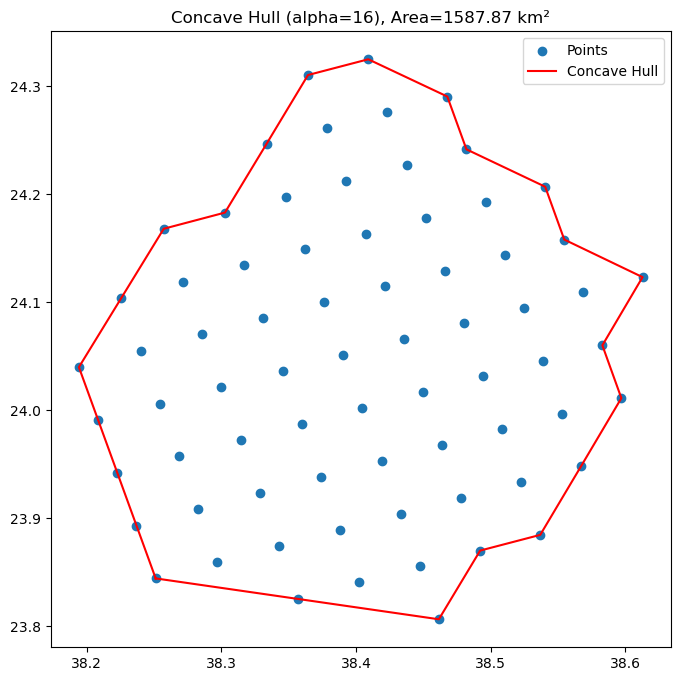

In [85]:
i = 18   # 11 12 17
lon = tropomi_data_cropped['longitude'][0].data
lat = tropomi_data_cropped['latitude'][0].data
points = np.array([lon[clusters==i], lat[clusters==i]]).T

import alphashape
from shapely.geometry import Point, Polygon
import geopandas as gpd

alpha = 16  # smaller = more concave, tune this
#alpha = alphashape.optimizealpha(points)
concave_hull = alphashape.alphashape(points, alpha)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(points[:, 0], points[:, 1], label='Points')
if isinstance(concave_hull, Polygon):
    x, y = concave_hull.exterior.xy
    ax.plot(x, y, color='red', label='Concave Hull')

concave_hull.area

gdf = gpd.GeoDataFrame(
    geometry=[concave_hull],
    crs="EPSG:4326"
)
utm_crs = gdf.estimate_utm_crs()
gdf_utm = gdf.to_crs(utm_crs)


area_m2 = gdf_utm.geometry.area.iloc[0]
area_area_km2 = area_m2 / 1_000_000

ax.set_title(f'Concave Hull (alpha={alpha}), Area={area_area_km2:.2f} km²')
ax.legend()
plt.show()

### v2

With SUPPORT_DATA/GEOLOCATION

In [259]:
tropomi_data_2 = xr.open_dataset(
    "/Users/eliaserv/Documents/VSCode_projects/SCEA/SCEA_developements/example_data/S5P_OFFL_L2__NO2____20220620T093952_20220620T112122_24275_02_020301_20220622T014827.nc",
    group="PRODUCT",
    engine="netcdf4",
    mask_and_scale=False,
)


In [260]:
tropomi_data_2["nitrogendioxide_tropospheric_column"]
point_coordinates = np.array(
    [tropomi_data_2['longitude'][0].data, 
     tropomi_data_2['latitude'][0].data]
     )
no2 = tropomi_data_2['nitrogendioxide_tropospheric_column'][0].data
qa_value = 0.75
qa_mask = (tropomi_data_2['qa_value'] > qa_value)[0]
no2_masked = np.where(qa_mask, no2, np.nan) # replace values where qa_mask is False with NaN

clusters_2 = scea.scea(
    coords=point_coordinates,   # spatial coordinates (lon,lat)
    values=no2_masked,          # values of points (NO2)     
    growth_limit=2.5,           # controls cluster size, higher values means smaller clusters
    detection_limit=6.1,        # controls cluster detection, higher values means less clusters
    local_box_size=3,           # radius of the local area around a starting point to be cropped and standardized (degrees for lon/lat)
    max_pts_start_radius=5,     # stopping criterion for a radiating point, maximum number of points in the starting radius
    metric="geodesic",          # distance metric ("euclidean", "haversine", "geodesic", "half_ellipse", "geodesic_half_ellipse")
    verbose=True                # whether to print progress messages
)



[Init] Starting SCEA with 4172 points.
[Init] Warning: 304055 points with NaN values found. They will be ignored.
[Init] Auto threshold set: 0.0001379. (detection_limit=)6.1 standard deviations from median.  (median=0.0000058, std=0.0000216)
[Start] SCEA: metric=geodesic, growth_limit=2.5, detection_limit=6.1, local_box_size=3, max_pts_start_radius=5, n_clusters=auto
[412] Cluster formed. | current max value: 0.0001379 | stopping threshold: 0.0001379
[Stop] Threshold reached: max active 0.0001379 <= 0.0001379
[Done] Total clusters found: 413, Time taken: 8.70 seconds


In [261]:
tropomi_geo = xr.open_dataset(
    "/Users/eliaserv/Documents/VSCode_projects/SCEA/SCEA_developements/example_data/S5P_OFFL_L2__NO2____20220620T093952_20220620T112122_24275_02_020301_20220622T014827.nc",
    group="PRODUCT/SUPPORT_DATA/GEOLOCATIONS",
    engine="netcdf4",
    mask_and_scale=False,
)
from pyproj import Geod


In [262]:
def clusters_areas(clusters, lon_bounds, lat_bounds, ignore_zero=True):

    geod = Geod(ellps="WGS84")
    areas = np.zeros(int(np.nanmax(clusters)+1), dtype='float64')

    for i in range(len(areas)):

        cluster_lon_bounds = lon_bounds[clusters == i]
        cluster_lat_bounds = lat_bounds[clusters == i]

        area_sum = 0        

        for j in range(len(cluster_lon_bounds)):
            lons = cluster_lon_bounds[j]
            lats = cluster_lat_bounds[j]
            area, _ = geod.polygon_area_perimeter(lons, lats)
            area_sum += abs(area) / 1e6  # convert to square kilometers

        areas[i] = area_sum

    if ignore_zero:
        areas = areas[1:]

    return areas


areas = clusters_areas(clusters_2, tropomi_geo["longitude_bounds"][0].data, tropomi_geo["latitude_bounds"][0].data, ignore_zero=True)
areas

array([4243.65963664, 4306.54692991, 4670.2534968 , 3749.31413154,
       1156.21030914, 1436.71183953, 3845.50873927, 5781.06247588,
       1692.81254028, 3360.78920436, 1840.14690641, 1555.53284101,
       2396.01426731, 2687.18119061, 3101.13285806, 3919.2967942 ,
       1391.3208645 , 4091.87289972, 2298.59460408, 2319.1475858 ,
       2324.21891536, 3629.46276409, 2490.22746398,  743.16349428,
       4285.13754887, 1456.03417977, 2520.1072352 , 4953.64935397,
       1898.86939678, 1447.59685824, 4933.05943797, 1227.55117101,
       1185.06575621,  641.06661292, 1646.95157045, 1511.35849894,
       1663.87050488, 1641.64355074,  757.22268871, 2581.80559017,
        769.03886747,  381.54026544,  329.86506846, 1293.47858614,
       2135.36312334, 3634.39584688,  439.98763029,  706.11786773,
       3887.86793082, 3458.42097315,  205.90306329,  920.00753485,
       2592.17351773, 1201.90293672,  326.8012697 ,   67.71811745,
       1456.95262626,  318.02793193,  296.11318916, 1131.70819

In [264]:
def calc_pixel_areas_km2(lon_bounds, lat_bounds, geod=Geod(ellps="WGS84")):
    """
    lon_bounds, lat_bounds: shape (n_pixels, 4)
    returns: area_km2, shape (n_pixels,)
    """
    shape = lon_bounds.shape[:-1]
    lon_bounds = lon_bounds.reshape(-1, 4)
    lat_bounds = lat_bounds.reshape(-1, 4)
    n = lon_bounds.shape[0]
    areas = np.empty(n, dtype=np.float64)

    for i in range(n):
        area, _ = geod.polygon_area_perimeter(
            lon_bounds[i], lat_bounds[i]
        )
        areas[i] = abs(area) * 1e-6  # m² → km²

    return areas.reshape(shape)


def cluster_areas_from_pixel_areas(
    clusters, lon_bounds, lat_bounds, ignore_zero=True
):
    """
    clusters: shape (n_pixels,), integer labels
    pixel_areas_km2: shape (n_pixels,)
    """

    # Flatten
    clusters = clusters.reshape(-1)
    lon_bounds = lon_bounds.reshape(-1, 4)
    lat_bounds = lat_bounds.reshape(-1, 4)

    geod = Geod(ellps="WGS84")

    if ignore_zero:
        clusters = clusters.astype(np.int64)
        valid = np.isfinite(clusters) & (clusters > 0)
        lon_bounds = lon_bounds[valid]
        lat_bounds = lat_bounds[valid]
        clusters = clusters[valid]
        mask = np.isfinite(clusters)
    else:
        mask = np.isfinite(clusters)
        lon_bounds = lon_bounds[mask]
        lat_bounds = lat_bounds[mask]
        clusters = clusters[mask].astype(np.int64)

    pixel_areas_km2 = calc_pixel_areas_km2(lon_bounds, lat_bounds, geod=geod)

    areas = np.bincount(
        clusters.astype(np.int64).flatten(),
        weights=pixel_areas_km2.flatten()
    )

    if ignore_zero:
        areas = areas[1:]

    return areas


lon_bounds = tropomi_geo["longitude_bounds"][0].data
lat_bounds = tropomi_geo["latitude_bounds"][0].data

cluster_areas = cluster_areas_from_pixel_areas(
    clusters_2, lon_bounds, lat_bounds, ignore_zero=True
)

cluster_areas[:5], cluster_areas[-5:]

<string>:1: RuntimeWarning: invalid value encountered in cast
/var/folders/p6/59vbd6tj4ts7d0rh5n3n2ms4rrn7dd/T/ipykernel_4035/673481426.py:37: RuntimeWarning: invalid value encountered in cast
  clusters = clusters.astype(np.int64)


(array([4243.65963664, 4306.54692991, 4670.2534968 , 3749.31413154,
        1156.21030914]),
 array([65.36582962, 47.08804144, 80.77059203, 64.27651377, 77.45843592]))

### How consistent is the areas per scaline?

In [91]:
areas.mean(axis=0)

np.float64(577.052111450806)

In [92]:
areas.std(axis=0)

np.float64(1051.8309310303896)

### Fast approximate

In [153]:
# TODO

## wind_magnitude

In [ ]:
def clusters_wind_magnitude(wind_u=None, wind_v=None, wind_magnitude=None, max_point_indices=None):
    """Wind magnitude at the location of the maximum point in each cluster. Provide either (wind_u, wind_v) or (wind_magnitude, wind_angle)."""

    if max_point_indices is None:
        raise ValueError("max_point_indices must be provided")

    if wind_magnitude is not None:
        return wind_magnitude[max_point_indices[:, 0], max_point_indices[:, 1]]

    elif wind_u is not None and wind_v is not None:
        wind_u_at_points = wind_u[max_point_indices[:, 0], max_point_indices[:, 1]]
        wind_v_at_points = wind_v[max_point_indices[:, 0], max_point_indices[:, 1]]
        return np.sqrt(wind_u_at_points**2 + wind_v_at_points**2)
    
    else:
        raise ValueError("Either (wind_u, wind_v) or (wind_magnitude) must be provided")
    
wind_magnitude = clusters_wind_magnitude(wind_u=era5_data['u10'].data, wind_v=era5_data['v10'].data, max_point_indices=max_point_indices)
wind_magnitude[:5], wind_magnitude[-5:]


IndexError: index 93 is out of bounds for axis 0 with size 11

## wind_direction

In [227]:
def clusters_wind_direction(wind_u=None, wind_v=None, wind_direction=None, max_point_indices=None):
    """Wind direction at the location of the maximum point in each cluster. Provide either (wind_u, wind_v) or (wind_magnitude, wind_angle)."""

    if max_point_indices is None:
        raise ValueError("max_point_indices must be provided")

    if wind_direction is not None:
        return wind_direction[max_point_indices[:, 0], max_point_indices[:, 1]]

    elif wind_u is not None and wind_v is not None:
        wind_u_at_points = wind_u[max_point_indices[:, 0], max_point_indices[:, 1]]
        wind_v_at_points = wind_v[max_point_indices[:, 0], max_point_indices[:, 1]]
        return np.arctan2(wind_v_at_points, wind_u_at_points) * (180 / np.pi) % 360
    
    else:
        raise ValueError("Either (wind_u, wind_v) or (wind_direction) must be provided")
    
wind_direction = clusters_wind_direction(wind_u=era5_data['u10'].data, wind_v=era5_data['v10'].data, max_point_indices=max_point_indices)
wind_direction[:5], wind_direction[-5:]

IndexError: index 93 is out of bounds for axis 0 with size 11

## is_weekend

In [286]:
def clusters_is_weekend(time, clusters=None, return_full_array=False, ignore_zero=True):
    """Whether each timestamp falls on a weekend (Sat/Sun)."""
    ts_days = np.asarray(time, dtype="datetime64[D]")  # handles str and datetime-like

    result = ~np.is_busday(ts_days)  # True for Sat/Sun

    if return_full_array:
        return np.zeros(int(np.nanmax(clusters)+1),dtype=bool) + result
    else:
        return result[0]


is_weekend = clusters_is_weekend(clusters=clusters, time=tropomi_data_cropped["time"].data, return_full_array=True)
len(is_weekend)

568

In [287]:
len(scea.clusters_day_of_week(clusters=clusters, time=tropomi_data_cropped["time"].data, return_full_array=True))

567

## is_on_land

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import geopandas as gpd



In [ ]:

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# optional reprojection
world = world.to_crs(epsg=4326)



In [ ]:
lat, lon = 59.89089253220171, 25.587255440967375

pt = Point(lon, lat)
is_land = world.contains(pt).any()
is_land

np.False_

In [240]:
def clusters_is_land(max_point_loc, map_data=None):
    """Whether the maximum point in each cluster falls on land. Uses the natural earth dataset via geopandas."""
    if map_data is None:
        map_data = gpd.read_file(
            "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
        )
        map_data = map_data.to_crs(epsg=4326)

    is_land_array = np.zeros(len(max_point_loc), dtype=bool)

    for i, (row_idx, col_idx) in enumerate(max_point_loc):
        lon = max_point_loc[i, 0]
        lat = max_point_loc[i, 1]
        pt = Point(lon, lat)
        is_land_array[i] = map_data.contains(pt).any()

    return is_land_array

is_land_array = clusters_is_land(max_point_locs, map_data=world)
is_land_array[:5], is_land_array[-5:]

(array([ True,  True,  True,  True,  True]),
 array([ True,  True,  True,  True,  True]))

In [239]:

def clusters_is_land_fast(max_point_locs, map_data=None):
    """Vectorized spatial join for checking if points are on land."""
    if map_data is None:
        map_data = gpd.read_file(
            "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
        )
        map_data = map_data.to_crs(epsg=4326)

    # Create GeoDataFrame from points
    points_gdf = gpd.GeoDataFrame(
        geometry=[Point(lon, lat) for lon, lat in max_point_locs],
        crs="EPSG:4326"
    )
    
    # Spatial join: points that intersect with map polygons are on land
    result = gpd.sjoin(points_gdf, map_data, how='left', predicate='intersects')
    is_land_array = result['index_right'].notna().values
    
    return is_land_array

is_land_array_fast = clusters_is_land_fast(max_point_locs, map_data=world)
is_land_array_fast[:10], is_land_array_fast[-10:]

(array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True]),
 array([False,  True,  True,  True,  True,  True,  True,  True,  True,
         True]))

## median_of_larger_box

In [242]:
def clusters_median_of_neighbourhood(values, max_point_locs, radius_km=10, lon_grid=None, lat_grid=None):
    """Median of values in a neighborhood around the maximum point location of each cluster. Radius is in kilometers. Uses haversine distance."""
    from haversine import haversine

    median_values = np.zeros(len(max_point_locs), dtype='float64')

    for i, (lon_c, lat_c) in enumerate(max_point_locs):
        neighbors = []
        for j in range(values.shape[0]):
            for k in range(values.shape[1]):
                if np.isnan(values[j, k]):
                    continue
                lon_p = lon_grid[j, k]
                lat_p = lat_grid[j, k]
                distance = haversine((lat_c, lon_c), (lat_p, lon_p))
                if distance <= radius_km:
                    neighbors.append(values[j, k])
        median_values[i] = np.nanmedian(neighbors) if neighbors else np.nan

    return median_values


clusters_median_neighborhood = clusters_median_of_neighbourhood(
    values=no2_masked,
    max_point_locs=max_point_locs,
    radius_km=10,
    lon_grid=tropomi_data_cropped['longitude'][0].data,
    lat_grid=tropomi_data_cropped['latitude'][0].data
)


KeyboardInterrupt: 

In [ ]:
clusters_median_neighborhood

array([5.67894254e-04, 5.09067788e-04, 4.95560118e-04, 3.80997051e-04,
       1.73955108e-04, 4.03592654e-04, 4.11353831e-04, 2.47076823e-04,
       3.77610151e-04, 2.77297397e-04, 2.51038262e-04, 3.60595470e-04,
       2.67779280e-04, 2.64306000e-04, 2.79535743e-04, 1.22268058e-04,
       3.03358305e-04, 1.83432770e-04, 9.48614106e-05, 2.10946804e-04,
       1.73701439e-04, 1.66832586e-04, 2.82250781e-04, 2.57972104e-04,
       1.21033096e-04, 2.69171986e-04, 2.34845924e-04, 1.28164858e-04,
       1.78165035e-04, 1.85843222e-04, 1.44092221e-04, 2.11731225e-04,
       1.12647234e-04, 1.05009465e-04, 1.49190964e-04, 1.40811433e-04,
       2.12516301e-04, 1.92856416e-04, 8.03637595e-05, 1.17393305e-04,
       1.25474471e-04, 1.60356431e-04, 1.50331383e-04, 1.89746614e-04,
       2.89416475e-05, 1.98495967e-04, 9.17727448e-05, 1.62445955e-04,
       1.44085687e-04, 8.66733535e-05, 1.28771950e-04, 1.80366653e-04,
       1.13249946e-04, 1.24425918e-04, 1.03805651e-04, 8.36667241e-05,
      

In [244]:
def clusters_median_of_neighbourhood_vectorized(values, max_point_locs, radius_km=10, lon_grid=None, lat_grid=None):
    """Vectorized version using broadcasting."""
    from haversine import haversine_vector
    
    median_values = np.zeros(len(max_point_locs), dtype='float64')
    
    # Flatten grid
    lons_flat = lon_grid.ravel()
    lats_flat = lat_grid.ravel()
    values_flat = values.ravel()
    valid = ~np.isnan(values_flat)
    
    lons_flat = lons_flat[valid]
    lats_flat = lats_flat[valid]
    values_flat = values_flat[valid]
    
    for i, (lon_c, lat_c) in enumerate(max_point_locs):
        # Vectorized: compute distance to all valid points at once
        distances = haversine_vector([(lat_c, lon_c)] * len(lons_flat), list(zip(lats_flat, lons_flat)))
        neighbors = values_flat[distances <= radius_km]
        median_values[i] = np.nanmedian(neighbors) if len(neighbors) > 0 else np.nan
    
    return median_values

clusters_median_neighborhood_vectorized = clusters_median_of_neighbourhood_vectorized(
    values=no2_masked,
    max_point_locs=max_point_locs,
    radius_km=10,
    lon_grid=tropomi_data_cropped['longitude'][0].data,
    lat_grid=tropomi_data_cropped['latitude'][0].data
)
clusters_median_neighborhood_vectorized

array([5.67894254e-04, 5.09067788e-04, 4.95560118e-04, 3.80997051e-04,
       1.73955108e-04, 4.03592654e-04, 4.11353831e-04, 2.47076823e-04,
       3.77610151e-04, 2.77297397e-04, 2.51038262e-04, 3.60595470e-04,
       2.67779280e-04, 2.64306000e-04, 2.79535743e-04, 1.22268058e-04,
       3.03358305e-04, 1.83432770e-04, 9.48614106e-05, 2.10946804e-04,
       1.73701439e-04, 1.66832586e-04, 2.82250781e-04, 2.57972104e-04,
       1.21033096e-04, 2.69171986e-04, 2.34845924e-04, 1.28164858e-04,
       1.78165035e-04, 1.85843222e-04, 1.44092221e-04, 2.11731225e-04,
       1.12647234e-04, 1.05009465e-04, 1.49190964e-04, 1.40811433e-04,
       2.12516301e-04, 1.92856416e-04, 8.03637595e-05, 1.17393305e-04,
       1.25474471e-04, 1.60356431e-04, 1.50331383e-04, 1.89746614e-04,
       2.89416475e-05, 1.98495967e-04, 9.17727448e-05, 1.62445955e-04,
       1.44085687e-04, 8.66733535e-05, 1.28771950e-04, 1.80366653e-04,
       1.13249946e-04, 1.24425918e-04, 1.03805651e-04, 8.36667241e-05,
      

In [245]:

from scipy.spatial import KDTree

def clusters_median_of_neighbourhood_kdtree(values, max_point_locs, radius_km=20, lon_grid=None, lat_grid=None):
    """Use KDTree for efficient spatial queries. Radius must be converted to degrees (~111 km/degree)."""
    
    median_values = np.zeros(len(max_point_locs), dtype='float64')
    
    # Flatten grid
    lons_flat = lon_grid.ravel()
    lats_flat = lat_grid.ravel()
    values_flat = values.ravel()
    valid = ~np.isnan(values_flat)
    
    lons_flat = lons_flat[valid]
    lats_flat = lats_flat[valid]
    values_flat = values_flat[valid]
    
    # Build KDTree on (lon, lat) points
    tree = KDTree(np.column_stack([lons_flat, lats_flat]))
    
    # Convert radius from km to degrees (approximate: 1 degree ≈ 111 km)
    radius_deg = radius_km / 111.0
    
    for i, (lon_c, lat_c) in enumerate(max_point_locs):
        # Find all points within radius_deg
        indices = tree.query_ball_point([lon_c, lat_c], radius_deg)
        neighbors = values_flat[indices]
        median_values[i] = np.nanmedian(neighbors) if len(neighbors) > 0 else np.nan
    
    return median_values

clusters_median_neighborhood_kdtree = clusters_median_of_neighbourhood_kdtree(
    values=no2_masked,
    max_point_locs=max_point_locs,
    radius_km=50,
    lon_grid=tropomi_data_cropped['longitude'][0].data,
    lat_grid=tropomi_data_cropped['latitude'][0].data
)
clusters_median_neighborhood_kdtree

array([1.30210145e-04, 8.40458160e-05, 6.00485910e-05, 7.33305278e-05,
       1.50677715e-05, 6.78973884e-05, 1.32432295e-04, 2.97380975e-05,
       3.17780068e-05, 5.07748045e-05, 6.51653463e-05, 1.09526591e-04,
       6.69292349e-05, 7.32843109e-05, 1.08020118e-04, 4.14900969e-05,
       1.13289832e-04, 4.01151119e-05, 2.19674512e-05, 4.90025486e-05,
       8.96097627e-05, 2.19759349e-05, 5.13509585e-05, 1.11414549e-04,
       7.18440569e-05, 6.47165871e-05, 6.73336690e-05, 3.72666909e-05,
       5.89381852e-05, 2.36597407e-05, 3.55758020e-05, 7.69779072e-05,
       7.11365938e-05, 5.37134183e-05, 2.09049485e-05, 6.72507012e-05,
       1.04259270e-04, 6.68297216e-05, 1.52063330e-05, 6.17864061e-05,
       1.96061701e-05, 2.22200251e-05, 3.22498090e-05, 1.25798339e-04,
       1.93022333e-05, 3.93979790e-05, 4.17822157e-05, 4.64820623e-05,
       5.56026789e-05, 2.05063443e-05, 3.65387605e-05, 2.83998797e-05,
       4.11388210e-05, 5.35872095e-05, 5.20990252e-05, 4.61567834e-05,
      

In [246]:
def clusters_median_of_neighbourhood_approx(values, max_point_locs, radius_km=20, lon_grid=None, lat_grid=None):
    """Approximate: only check grid cells within bounding box."""
    import math
    
    median_values = np.zeros(len(max_point_locs), dtype='float64')
    
    # Estimate degrees per km (varies by latitude, use average)
    deg_per_km = 1.0 / 111.0
    radius_deg = radius_km * deg_per_km
    
    for i, (lon_c, lat_c) in enumerate(max_point_locs):
        # Bounding box instead of radius circle
        lon_mask = (lon_grid >= lon_c - radius_deg) & (lon_grid <= lon_c + radius_deg)
        lat_mask = (lat_grid >= lat_c - radius_deg) & (lat_grid <= lat_c + radius_deg)
        mask = lon_mask & lat_mask & ~np.isnan(values)
        
        neighbors = values[mask]
        median_values[i] = np.nanmedian(neighbors) if len(neighbors) > 0 else np.nan
    
    return median_values

clusters_median_neighborhood_approx = clusters_median_of_neighbourhood_approx(
    values=no2_masked,
    max_point_locs=max_point_locs,
    radius_km=10,
    lon_grid=tropomi_data_cropped['longitude'][0].data,
    lat_grid=tropomi_data_cropped['latitude'][0].data
)
clusters_median_neighborhood_approx

array([5.52878890e-04, 4.83599957e-04, 4.45785525e-04, 3.35625111e-04,
       1.73955108e-04, 4.01004538e-04, 3.83214880e-04, 2.47076823e-04,
       3.33428034e-04, 2.77297397e-04, 2.51038262e-04, 3.60595470e-04,
       2.67779280e-04, 2.64306000e-04, 2.67013180e-04, 9.00846208e-05,
       3.03358305e-04, 1.44928927e-04, 8.70427757e-05, 2.15033564e-04,
       1.49065861e-04, 1.18995122e-04, 2.82250781e-04, 2.57972104e-04,
       1.21033096e-04, 2.69171986e-04, 2.34845924e-04, 1.11902023e-04,
       1.93327418e-04, 1.85843222e-04, 1.76743590e-04, 2.11731225e-04,
       1.13491624e-04, 1.05009465e-04, 1.73609864e-04, 1.40811433e-04,
       2.15655353e-04, 1.93864005e-04, 8.03637595e-05, 1.17393305e-04,
       1.25474471e-04, 1.60356431e-04, 1.47332466e-04, 2.04292359e-04,
       2.89416475e-05, 1.98495967e-04, 5.08141711e-05, 1.62445955e-04,
       1.46900449e-04, 7.95077431e-05, 1.13911345e-04, 1.00149737e-04,
       1.13249946e-04, 1.30469183e-04, 1.02497470e-04, 9.51126058e-05,
      

In [ ]:
import numpy as np
from haversine import haversine_vector, Unit
from scipy.spatial import KDTree


In [248]:

def clusters_median_of_neighbourhood_bbox(
    values,
    max_point_locs,
    lon_grid,
    lat_grid,
    radius_km=10.0
):
    median_values = np.full(len(max_point_locs), np.nan)

    lons = lon_grid.ravel()
    lats = lat_grid.ravel()
    vals = values.ravel()

    valid = ~np.isnan(vals)
    lons = lons[valid]
    lats = lats[valid]
    vals = vals[valid]

    for i, (lon_c, lat_c) in enumerate(max_point_locs):
        dlat = radius_km / 111.32
        dlon = radius_km / (111.32 * np.cos(np.deg2rad(lat_c)))

        bbox_mask = (
            (lats >= lat_c - dlat) & (lats <= lat_c + dlat) &
            (lons >= lon_c - dlon) & (lons <= lon_c + dlon)
        )

        if not np.any(bbox_mask):
            continue

        # Approximate local distance in km
        dx = (lons[bbox_mask] - lon_c) * 111.32 * np.cos(np.deg2rad(lat_c))
        dy = (lats[bbox_mask] - lat_c) * 111.32
        dists = np.sqrt(dx * dx + dy * dy)

        neighbors = vals[bbox_mask][dists <= radius_km]
        if neighbors.size > 0:
            median_values[i] = np.nanmedian(neighbors)

    return median_values

clusters_median_neighborhood_bbox = clusters_median_of_neighbourhood_bbox(
    values=no2_masked,
    max_point_locs=max_point_locs,
    lon_grid=tropomi_data_cropped['longitude'][0].data,
    lat_grid=tropomi_data_cropped['latitude'][0].data,
    radius_km=50
)
clusters_median_neighborhood_bbox

array([1.29016102e-04, 8.26403339e-05, 5.71746496e-05, 6.30079012e-05,
       1.45702543e-05, 6.18800332e-05, 1.30702945e-04, 2.79586711e-05,
       3.16765945e-05, 5.02149778e-05, 6.19858693e-05, 1.13717331e-04,
       6.55225958e-05, 7.10429595e-05, 9.34515265e-05, 4.10971479e-05,
       1.04729552e-04, 3.82192848e-05, 2.17310953e-05, 4.62033677e-05,
       8.84786350e-05, 1.86900361e-05, 5.05039825e-05, 1.13717331e-04,
       6.97769283e-05, 6.10696370e-05, 5.87305294e-05, 3.49637194e-05,
       5.89381852e-05, 2.38063640e-05, 3.31693336e-05, 7.29674939e-05,
       6.67105342e-05, 5.14070452e-05, 1.96738401e-05, 6.43716485e-05,
       9.83010541e-05, 6.43674357e-05, 1.38908899e-05, 6.16120597e-05,
       1.96061701e-05, 2.12678169e-05, 3.16459409e-05, 1.15909919e-04,
       1.92509542e-05, 3.68044384e-05, 4.03730883e-05, 4.45992773e-05,
       5.26550830e-05, 2.05063443e-05, 3.47861169e-05, 2.67485320e-05,
       4.10105240e-05, 5.15047577e-05, 4.68387152e-05, 4.64152690e-05,
      

In [252]:
# Todo make sense of this 
from scipy.spatial import KDTree

def build_latlon_kdtree(lon_grid, lat_grid, values):
    lons = lon_grid.ravel()
    lats = lat_grid.ravel()
    vals = values.ravel()

    valid = ~np.isnan(vals)
    lons = lons[valid]
    lats = lats[valid]
    vals = vals[valid]

    # Scale longitude by cos(latitude)
    x = lons * np.cos(np.deg2rad(lats))
    y = lats

    tree = KDTree(np.column_stack((x, y)))

    return tree, lons, lats, vals


def clusters_median_of_neighbourhood_kdtree_exact(
    tree,
    lons,
    lats,
    vals,
    max_point_locs,
    radius_km
):
    medians = np.full(len(max_point_locs), np.nan)

    radius_deg = radius_km / 111.32  # rough upper bound

    for i, (lon_c, lat_c) in enumerate(max_point_locs):
        xc = lon_c * np.cos(np.deg2rad(lat_c))
        yc = lat_c

        idx = tree.query_ball_point([xc, yc], radius_deg)
        if not idx:
            continue

        candidates = np.column_stack((lats[idx], lons[idx]))
        center = np.column_stack((
            np.full(len(idx), lat_c),
            np.full(len(idx), lon_c),
        ))

        dists = haversine_vector(candidates, center, Unit.KILOMETERS)

        neighbors = vals[idx][dists <= radius_km]
        if neighbors.size > 0:
            medians[i] = np.nanmedian(neighbors)

    return medians


tree, lons, lats, vals = build_latlon_kdtree(
    tropomi_data_cropped['longitude'][0].data,
    tropomi_data_cropped['latitude'][0].data,
    no2_masked
)  
clusters_median_neighborhood_kdtree_exact = clusters_median_of_neighbourhood_kdtree_exact(
    tree,
    lons,
    lats,
    vals,
    max_point_locs,
    radius_km=50
)
clusters_median_neighborhood_kdtree_exact

array([1.32204004e-04, 8.42924128e-05, 5.79016159e-05, 6.97590294e-05,
       1.48911640e-05, 6.09495364e-05, 1.30555840e-04, 2.86256945e-05,
       3.12902666e-05, 5.09974125e-05, 6.42168161e-05, 1.15084127e-04,
       6.59492725e-05, 6.62964812e-05, 9.44805506e-05, 4.23373931e-05,
       1.21308840e-04, 4.00528697e-05, 2.19487811e-05, 4.78832117e-05,
       9.11176394e-05, 1.93292617e-05, 5.44557661e-05, 1.16450916e-04,
       7.01780446e-05, 6.10696370e-05, 7.01368190e-05, 3.61796920e-05,
       6.13836091e-05, 2.57907868e-05, 3.35919358e-05, 7.60133553e-05,
       6.75237534e-05, 5.15391039e-05, 2.02015017e-05, 6.61789963e-05,
       9.83010541e-05, 6.36219556e-05, 1.43043326e-05, 6.60945807e-05,
       2.00501036e-05, 2.18690093e-05, 3.25480250e-05, 1.16833209e-04,
       1.90655228e-05, 3.96514624e-05, 4.04146922e-05, 5.04920063e-05,
       5.78310573e-05, 2.04475837e-05, 3.48083158e-05, 2.81117409e-05,
       4.07544103e-05, 5.09589809e-05, 4.88488186e-05, 4.57245478e-05,
      

## is_max_point_on_edge_of_cluster

In [253]:
# is max point on edge of cluter
# define edge as having at least one neighbor that is not in the cluster (or is nan)

def clusters_is_max_point_on_edge(clusters, max_point_indices, ignore_zero=True):
    is_on_edge = np.zeros(len(max_point_indices), dtype=bool)

    for i, (row_idx, col_idx) in enumerate(max_point_indices):
        cluster_id = i + 1 if ignore_zero else i
        neighbors = clusters[max(0, row_idx-1):row_idx+2, max(0, col_idx-1):col_idx+2].flatten()
        is_on_edge[i] = np.any((neighbors != cluster_id) & ~np.isnan(neighbors))

    return is_on_edge

is_on_edge = clusters_is_max_point_on_edge(clusters, max_point_indices, ignore_zero=True)
is_on_edge



array([False, False, False, False, False, False, False, False, False,
       False,  True,  True, False,  True, False, False,  True, False,
       False, False, False, False,  True,  True, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False,  True, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
        True, False, False, False, False,  True,  True,  True, False,
       False, False, False, False, False, False, False, False,  True,
       False, False,  True,  True, False, False,  True, False, False,
        True, False, False, False, False,  True, False, False, False,
       False, False,  True, False, False, False, False, False, False,
        True,  True,  True,  True, False,  True, False, False, False,
        True, False,  True, False,  True, False,  True, False,  True,
       False,  True,

## is_plume_connected_to_nans

In [84]:
i=170
j=370
clusters[10+i:40+i, 10+j:21+j]

array([[ 14.,  40.,  40.,  40.,  40.,  40.,  40., 386.,   0.,   0.,   0.],
       [ 14.,  40.,  40.,  40.,  40.,  40.,  40., 386.,   0.,   0.,   0.],
       [ 14.,  40.,  40.,  40.,  40.,  40.,  40.,   0.,   0.,   0.,   0.],
       [ 14.,  40.,  40.,  40.,  40.,  40., 410.,   0.,   0.,   0.,   0.],
       [210.,  40.,  40.,  40.,  40.,  40., 410.,   0.,   0.,   0.,   0.],
       [210.,  40.,  40.,  40.,  40.,  40., 410.,   0.,   0.,   0.,   0.],
       [144., 210.,  40.,  40., 410., 410., 410.,   0.,   0.,   0.,   0.],
       [144., 210., 210., 410., 410., 410., 410.,   0.,   0.,   0.,   0.],
       [144., 210., 210., 410., 410., 410., 410.,   0.,   0.,   0.,   0.],
       [144., 144., 210., 410., 410., 410., 410.,   0.,   0.,   0.,   0.],
       [144., 210., 410., 410., 410., 410., 410.,   0.,   0.,   0.,   0.],
       [144., 144., 410., 410., 410., 410., 410.,   0.,   0.,   0.,   0.],
       [144., 410., 410., 410., 410., 410., 410.,   0.,   0.,   0.,   0.],
       [144., 410., 410.,

In [110]:
i=900
j=0
clusters[i:30+i, j:11+j]

array([[nan, nan, nan, nan,  0.,  0.,  0.,  0.,  0.,  0., nan],
       [nan, nan, nan,  0.,  0.,  0.,  0.,  0.,  0.,  0., nan],
       [nan, nan,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [nan, nan, nan,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [nan, nan, nan,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [nan, nan, nan,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [nan, nan, nan,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [nan, nan,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [nan, nan,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [nan, nan,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [nan, nan,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [nan, nan,  0.,  0., nan, nan, nan, nan,  0.,  0.,  0.],
       [nan, nan,  0., nan, nan, nan, nan, nan, nan,  0.,  0.],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan,  0.,  0.],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan,  0.,  0.],
       [nan, nan, nan, nan, nan,  0., na

In [24]:
# is plume connected to nans or the edge of the image

def clusters_is_plume_connected_to_nans_or_edge(clusters, ignore_zero=True):
    is_connected = np.zeros(int(np.nanmax(clusters)+1), dtype=bool)

    for cluster_id in range(1 if ignore_zero else 0, int(np.nanmax(clusters))+1):
        cluster_mask = (clusters == cluster_id)
        if not np.any(cluster_mask):
            continue

        # Check if any point in the cluster is adjacent to a nan or the edge
        for row_idx, col_idx in zip(*np.where(cluster_mask)):
            neighbors = clusters[max(0, row_idx-1):row_idx+2, max(0, col_idx-1):col_idx+2].flatten()
            if np.any(np.isnan(neighbors)):
                is_connected[cluster_id] = True
                break
    return is_connected[1:] if ignore_zero else is_connected

is_connected = clusters_is_plume_connected_to_nans_or_edge(clusters, ignore_zero=True)
is_connected

array([False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False,  True,  True, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False,  True, False, False,  True,  True,
       False, False, False, False, False, False, False,  True, False,
       False, False, False,  True, False,  True,  True, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
        True, False,

In [79]:
def clusters_is_plume_connected_to_nans_or_edge(clusters, ignore_zero=True):

    # pad the clusters array with nans
    clusters_pad = np.pad(clusters, pad_width=1, mode='constant', constant_values=np.nan)

    # create a mask of the same shape as clusters, where True indicates points that are nans or on the edge
    isnan = np.isnan(clusters_pad)

    is_connected = np.zeros(int(np.nanmax(clusters)+1), dtype=bool)

    for cluster_id in range(1 if ignore_zero else 0, int(np.nanmax(clusters))+1):
        cluster_mask = (clusters == cluster_id)
        if not np.any(cluster_mask):
            continue

        # Check if any point in the cluster is adjacent to a nan or the edge
        for row_idx, col_idx in zip(*np.where(cluster_mask)):
            neighbors = isnan[max(0, row_idx-1):row_idx+2, max(0, col_idx-1):col_idx+2].flatten()
            if np.any(neighbors):
                is_connected[cluster_id] = True
                break
    return is_connected[1:] if ignore_zero else is_connected

is_connected = clusters_is_plume_connected_to_nans_or_edge(clusters, ignore_zero=True)
is_connected

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False,  True, False, False,  True,  True,
       False, False, False, False, False, False, False,  True, False,
       False, False, False,  True, False,  True, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
        True, False,

In [129]:
def clusters_is_plume_connected_to_nans_or_edge_fast(
    clusters,
    ignore_zero=True,
    connectivity=8,   # 4 or 8
):
    c = np.asarray(clusters, dtype=float)
    n_clusters = int(np.nanmax(c)) + 1
    out = np.zeros(n_clusters, dtype=bool)

    # Pad with NaN so touching the image boundary counts as touching edge
    p = np.pad(c, 1, mode="constant", constant_values=np.nan)
    center = p[1:-1, 1:-1]

    if connectivity == 4:
        # N, S, W, E
        touch_nan = (
            np.isnan(p[:-2, 1:-1]) |   # north
            np.isnan(p[2:, 1:-1])  |   # south
            np.isnan(p[1:-1, :-2]) |   # west
            np.isnan(p[1:-1, 2:])       # east
        )
    elif connectivity == 8:
        # N, S, W, E + diagonals
        touch_nan = (
            np.isnan(p[:-2, :-2]) | np.isnan(p[:-2, 1:-1]) | np.isnan(p[:-2, 2:]) |
            np.isnan(p[1:-1, :-2])                           | np.isnan(p[1:-1, 2:]) |
            np.isnan(p[2:, :-2])  | np.isnan(p[2:, 1:-1])  | np.isnan(p[2:, 2:])
        )
    else:
        raise ValueError("connectivity must be 4 or 8")

    valid = np.isfinite(center)
    if ignore_zero:
        valid &= (center > 0)

    touched_labels = center[valid & touch_nan].astype(np.int64)
    if touched_labels.size:
        # Slightly faster than unique for this use case
        hit = np.bincount(touched_labels, minlength=n_clusters) > 0
        out |= hit

    return out[1:] if ignore_zero else out

is_connected_fast = clusters_is_plume_connected_to_nans_or_edge_fast(clusters, ignore_zero=True, connectivity=8)
is_connected_fast

array([False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False,  True,  True, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False,  True, False, False,  True,  True,
       False, False, False, False, False, False, False,  True, False,
       False, False, False,  True, False,  True,  True, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False,  True,
        True, False,

In [125]:
print(is_connected_fast[12-1])
print(np.where(clusters==12))

i=315
j=415
clusters[i:30+i, j:11+j]

True
(array([317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327]), array([421, 421, 421, 421, 421, 421, 421, 421, 421, 421, 421]))


array([[ 27.,  27.,  27., 187., 187., 432., 432., 122.,  26.,  23.,  48.],
       [ 27.,  27.,  27., 187., 187.,  17., 432., 122.,  26.,  23.,  48.],
       [145.,  27.,  27.,  27.,  27.,  17.,  12., 122.,  26.,  23.,  48.],
       [145.,  27.,  27.,  27.,  27.,  17.,  12., 122.,  26.,  23.,  48.],
       [145.,  27.,  27.,  27.,  27.,  17.,  12.,  24.,  26.,  23.,  48.],
       [145.,  27.,  27.,  27.,  27.,  17.,  12.,  24.,  26.,  23.,  48.],
       [145.,  27.,  27.,  27.,  27.,  17.,  12.,  24.,  64.,  23.,  48.],
       [145.,  27.,  27.,  27.,  27.,  17.,  12.,  24.,  64.,  23.,  48.],
       [145.,  27.,  27.,  27.,  27.,  17.,  12.,  24.,  64.,  23.,  48.],
       [262.,  27.,  27.,  27.,  27.,  17.,  12.,  24.,  64.,  23.,  48.],
       [262., 442.,  27.,  27.,  27.,  17.,  12.,  24.,  64.,   0.,   0.],
       [262., 442.,  27.,  27.,  27.,  17.,  12.,  24.,  64.,   0.,   0.],
       [262., 442.,  27.,  27.,  27.,  17.,  12.,  24.,  64.,   0.,   0.],
       [262., 442., 442.,

In [123]:
print(is_connected_fast[17-1])
print(np.where(clusters==16))

i=315
j=415
clusters[i:30+i, j:11+j]

True
(array([370, 370, 370, 371, 371, 371, 371, 371, 371, 372, 372, 372, 372,
       372, 372, 372, 372, 373, 373, 373, 373, 373, 373, 373, 373, 374,
       374, 374, 374, 374, 374, 374, 374, 375, 375, 375, 375, 375, 376,
       376, 376, 376, 376, 377, 377, 377, 377]), array([151, 152, 153, 150, 151, 152, 153, 154, 155, 149, 150, 151, 152,
       153, 154, 155, 156, 150, 151, 152, 153, 154, 155, 156, 157, 151,
       152, 153, 154, 155, 156, 157, 158, 153, 156, 157, 158, 159, 154,
       155, 156, 157, 158, 154, 155, 156, 157]))


array([[ 27.,  27.,  27., 187., 187., 432., 432., 122.,  26.,  23.,  48.],
       [ 27.,  27.,  27., 187., 187.,  17., 432., 122.,  26.,  23.,  48.],
       [145.,  27.,  27.,  27.,  27.,  17.,  12., 122.,  26.,  23.,  48.],
       [145.,  27.,  27.,  27.,  27.,  17.,  12., 122.,  26.,  23.,  48.],
       [145.,  27.,  27.,  27.,  27.,  17.,  12.,  24.,  26.,  23.,  48.],
       [145.,  27.,  27.,  27.,  27.,  17.,  12.,  24.,  26.,  23.,  48.],
       [145.,  27.,  27.,  27.,  27.,  17.,  12.,  24.,  64.,  23.,  48.],
       [145.,  27.,  27.,  27.,  27.,  17.,  12.,  24.,  64.,  23.,  48.],
       [145.,  27.,  27.,  27.,  27.,  17.,  12.,  24.,  64.,  23.,  48.],
       [262.,  27.,  27.,  27.,  27.,  17.,  12.,  24.,  64.,  23.,  48.],
       [262., 442.,  27.,  27.,  27.,  17.,  12.,  24.,  64.,   0.,   0.],
       [262., 442.,  27.,  27.,  27.,  17.,  12.,  24.,  64.,   0.,   0.],
       [262., 442.,  27.,  27.,  27.,  17.,  12.,  24.,  64.,   0.,   0.],
       [262., 442., 442.,

## connected_plume_ids

In [130]:
def clusters_connected_plumes(clusters, ignore_zero=True):
    """
    For each cluster, outputs a list of other clusters that are connected to it (i.e. have at least one point adjacent to a point in the other cluster).
    """

    # pad the clusters array with nans
    clusters_pad = np.pad(clusters, pad_width=1, mode='constant', constant_values=np.nan)

    n_clusters = int(np.nanmax(clusters)) + 1
    if ignore_zero:
        n_clusters -= 1

    connected_clusters = [set() for _ in range(n_clusters)]

    for cluster_id in range(1 if ignore_zero else 0, int(np.nanmax(clusters))+1):
        cluster_mask = (clusters == cluster_id)
        if not np.any(cluster_mask):
            continue

        for row_idx, col_idx in zip(*np.where(cluster_mask)):
            neighbors = clusters_pad[max(0, row_idx):row_idx+3, max(0, col_idx):col_idx+3].flatten()
            neighbor_clusters = set(neighbors[~np.isnan(neighbors)].astype(int))
            neighbor_clusters.discard(cluster_id)  # remove self
            connected_clusters[cluster_id - (1 if ignore_zero else 0)].update(neighbor_clusters)

    return connected_clusters

connected_clusters = clusters_connected_plumes(clusters, ignore_zero=True)
connected_clusters[:5], connected_clusters[-5:]

([{np.int64(0),
   np.int64(15),
   np.int64(44),
   np.int64(69),
   np.int64(96),
   np.int64(294),
   np.int64(415)},
  {np.int64(7), np.int64(21), np.int64(102), np.int64(237)},
  {np.int64(0), np.int64(21), np.int64(70), np.int64(91)},
  {np.int64(0),
   np.int64(55),
   np.int64(60),
   np.int64(142),
   np.int64(143),
   np.int64(154),
   np.int64(302)},
  {np.int64(0)}],
 [{np.int64(0)},
  {np.int64(0), np.int64(333)},
  {np.int64(0), np.int64(181), np.int64(560)},
  {np.int64(0)},
  {np.int64(0), np.int64(177), np.int64(238), np.int64(255)}])

In [147]:
import numpy as np

def clusters_connected_plumes_fast(clusters, ignore_zero=True, connectivity=8):
    """
    For each cluster, return a set of adjacent cluster IDs.
    connectivity: 4 or 8

    Behavior with ignore_zero:
    - ignore_zero=False: returns sets for clusters 0..N
    - ignore_zero=True: returns sets for clusters 1..N
      but 0 is still included inside those sets if adjacent
    """
    c = np.asarray(clusters, dtype=float)
    n_all = int(np.nanmax(c)) + 1

    # Output layout
    n_out = n_all - 1 if ignore_zero else n_all
    connected = [set() for _ in range(n_out)]

    def collect_pairs(a, b):
        # Finite neighboring labels that differ
        valid = np.isfinite(a) & np.isfinite(b) & (a != b)

        if not np.any(valid):
            return np.empty((0, 2), dtype=np.int64)

        p = np.stack(
            [a[valid].astype(np.int64), b[valid].astype(np.int64)],
            axis=1
        )

        # Undirected edge: (i, j) == (j, i)
        p.sort(axis=1)

        # Remove duplicates
        return np.unique(p, axis=0)

    # 4-neighborhood: horizontal + vertical
    pair_blocks = [
        collect_pairs(c[:, :-1], c[:, 1:]),   # left-right
        collect_pairs(c[:-1, :], c[1:, :])    # up-down
    ]

    # 8-neighborhood adds diagonals
    if connectivity == 8:
        pair_blocks.append(collect_pairs(c[:-1, :-1], c[1:, 1:]))  # down-right
        pair_blocks.append(collect_pairs(c[:-1, 1:], c[1:, :-1]))  # down-left
    elif connectivity != 4:
        raise ValueError("connectivity must be 4 or 8")

    pairs = np.concatenate(pair_blocks, axis=0)
    if pairs.size == 0:
        return connected

    pairs = np.unique(pairs, axis=0)

    def idx_in_output(label):
        if ignore_zero:
            if label == 0:
                return None
            return label - 1
        return label

    # Build symmetric adjacency sets
    for a, b in pairs:
        ia = idx_in_output(a)
        ib = idx_in_output(b)

        # Add b into a's set if a has an output slot
        if ia is not None:
            connected[ia].add(int(b))

        # Add a into b's set if b has an output slot
        if ib is not None:
            connected[ib].add(int(a))

    return connected


connected_clusters_fast = clusters_connected_plumes_fast(clusters, ignore_zero=True, connectivity=8)
connected_clusters_fast

[{0, 15, 44, 69, 96, 294, 415},
 {7, 21, 102, 237},
 {0, 21, 70, 91},
 {0, 55, 60, 142, 143, 154, 302},
 {0},
 {0, 38, 88, 157, 170, 177, 193, 211, 238, 255, 282, 356, 454, 483},
 {2, 21, 84, 102, 123, 158},
 {0},
 {0, 174, 198},
 {0, 11, 326, 385},
 {0, 10, 14, 25, 326, 410},
 {0, 17, 24, 122, 432},
 {0, 85, 112, 230, 259, 314, 323, 385, 519, 555},
 {11, 25, 32, 40, 81, 144, 210, 301, 410},
 {0, 1, 96, 235, 261, 415},
 {0, 151, 169, 359, 361, 451, 520, 560},
 {0, 12, 27, 187, 432},
 {0, 297, 331},
 {0},
 {0, 111, 291, 337},
 {0, 2, 3, 7, 70, 123, 237, 305},
 {0},
 {0, 26, 48, 64},
 {12, 26, 64, 122},
 {11, 14, 112, 144, 301, 323, 326, 385},
 {0, 23, 24, 64, 122},
 {0, 17, 145, 187, 262, 442},
 {0, 131, 421, 453, 466},
 {0, 93, 196, 271, 339, 343, 490},
 {0},
 {0},
 {0, 14, 81, 163, 275, 410},
 {36, 101, 110, 118, 167, 168, 225, 280},
 {0, 54, 251, 439},
 {0},
 {0, 33, 92, 110, 129, 167, 502},
 {0, 71, 128, 135, 188, 213, 217, 270},
 {0, 6, 88, 124, 150, 171, 202, 238, 263, 353, 549},


## mean_q_value

In [156]:

def clusters_mean_q_value(clusters, qa_values, ignore_zero=True):
    """
    Mean qa_value per cluster label.

    Parameters
    ----------
    clusters : array-like
        Cluster label grid (can contain NaN). Expected integer-like labels: 0,1,2,...
    qa_values : array-like
        qa_value grid, same shape as clusters.
    ignore_zero : bool
        If True, exclude cluster 0 from returned array.

    Returns
    -------
    np.ndarray
        Mean qa_value per cluster.
        - If ignore_zero=False: index i corresponds to cluster i.
        - If ignore_zero=True: result[0] corresponds to cluster 1.
        Clusters with no valid qa pixels are returned as NaN.
    """
    c = np.asarray(clusters, dtype=float)
    q = np.asarray(qa_values, dtype=float)

    if c.shape != q.shape:
        raise ValueError("clusters and qa_values must have the same shape")

    # Keep only finite labels and finite qa values
    valid = np.isfinite(c) & np.isfinite(q)
    if not np.any(valid):
        return np.array([], dtype=float)

    labels = c[valid].astype(np.int64, copy=False)
    qa = q[valid]

    n_labels = int(np.nanmax(c)) + 1

    # Sum and counts per label
    sums = np.bincount(labels, weights=qa, minlength=n_labels)
    counts = np.bincount(labels, minlength=n_labels)

    means = np.full(n_labels, np.nan, dtype=float)
    nonzero = counts > 0
    means[nonzero] = sums[nonzero] / counts[nonzero]

    return means[1:] if ignore_zero else means


mean_qa_per_cluster = clusters_mean_q_value(clusters, tropomi_data_cropped['qa_value'][0].data, ignore_zero=True)
mean_qa_per_cluster

array([1.        , 1.        , 0.99506173, 0.97833334, 1.        ,
       1.        , 0.9969697 , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       0.98957447, 1.        , 0.99901408, 1.        , 1.        ,
       1.        , 0.98817204, 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       0.98714285, 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.98217054, 1.        , 0.96153845, 1.        ,
       1.        , 1.        , 0.99555555, 1.        , 0.98709677,
       1.        , 0.99054054, 1.        , 1.        , 0.94999999,
       0.99164383, 1.        , 1.        , 1.        , 0.99548387,
       1.        , 1.        , 1.        , 0.99117647, 0.988     ,
       1.        , 0.98947368, 1.        , 1.        , 0.99553192,
       0.99583333, 1.        , 0.99523809, 1.        , 0.97855856,
       0.94423076, 1.        , 1.        , 1.        , 1.     

In [11]:
print("\rasdf", end='', flush=True)
print('\r' + 'skipidi', end='', flush=True)
print('\r' + 'skipidi', end='', flush=True)
print('\r' + 'skipidi', end='', flush=True)


skipidi

In [ ]:

"""
File 4/23 *progress bar*. Time left: 1m 20s | Elapsed time: 2m 30s | Total time: 3m 50s

Preprocessing: [crop to bbox, quality filter, discard small files, denoise butterworth, nan gaussian filter, local standardization (median+mad), denoise butterworth]
                [ done , done , done , done , done ,     ,     ,     ,     ,     ] Time: 12.3s

Finding clusters: [{cluster_id - 1}] Cluster formed. | current max value: {active_values.max():.7f} | stopping threshold: {point_value_threshold:.7f}"

Extracting features: [max value, mean value, area, median of neighborhood, wind speed at max point, is weekend, is land, is connected to nans/edge]
                [ done , done , done , done , done ,     ,     ,     ,     ,     ] Time: 4.3s

"""

In [13]:
from tqdm import tqdm
from time import sleep

tasks = ["Load data", "Preprocess", "Train model", "Evaluate"]

bars = [
    tqdm(total=100, desc=task, position=i)
    for i, task in enumerate(tasks)
]

for step in range(100):
    sleep(0.2)
    for bar in bars:
        bar.update(1)

for bar in bars:
    bar.close()

Load data:   0%|          | 0/100 [00:00<?, ?it/s]


Load data:   1%|          | 1/100 [00:00<00:20,  4.82it/s]


Load data:   2%|▏         | 2/100 [00:00<00:20,  4.83it/s]


Load data:   3%|▎         | 3/100 [00:00<00:20,  4.83it/s]


Load data:   4%|▍         | 4/100 [00:00<00:19,  4.81it/s]


Load data:   5%|▌         | 5/100 [00:01<00:19,  4.81it/s]


Load data:   6%|▌         | 6/100 [00:01<00:19,  4.81it/s]


Load data:   7%|▋         | 7/100 [00:01<00:19,  4.79it/s]


Load data:   8%|▊         | 8/100 [00:01<00:19,  4.79it/s]


Load data:   9%|▉         | 9/100 [00:01<00:18,  4.79it/s]


Load data:  10%|█         | 10/100 [00:02<00:18,  4.80it/s]


Load data:  11%|█         | 11/100 [00:02<00:18,  4.80it/s]


Load data:  12%|█▏        | 12/100 [00:02<00:18,  4.80it/s]


Load data:  13%|█▎        | 13/100 [00:02<00:18,  4.76it/s]


Load data:  14%|█▍        | 14/100 [00:02<00:18,  4.73it/s]


Load data:  15%|█▌        | 15/100 [00:03<00:18,  4.71it/s]


Load data:  16%|█▌        